# データ分析 01：福岡市人口動態分析
## 中央区における流入依存度の推移

### 分析対象

- **データソース**: Bodik API（福岡市データポータル）
- **統計対象**: 日本人人口動態（区別・圏域別）
- **期間**: 令和6年～令和7年（月次データ）
- **主要指標**: 流入依存度（市外からの転入 ÷ 総転入数）

### 分析範囲

本分析は統計データの客観的な記述に留めます。データの解釈や見解については、99の統合分析レポートを参照してください。

In [1]:
## セクション1: 環境セットアップとライブラリのインポート
import pandas as pd
import requests
import io

## 1. 環境セットアップとライブラリのインポート

分析に必要なPythonライブラリをインポートします。Bodik APIからのデータ取得、データフレーム操作、可視化に必要なパッケージを一括で読み込みます。

In [2]:
# ==============================================================================
# セクション2: Bodik APIからのデータ取得と統合
# ==============================================================================
# 福岡市登録人口（行政区別・人口動態）
# https://data.bodik.jp/dataset/401307_population_touroku_demographic

import requests
import pandas as pd
import re

def fetch_fukuoka_data_api(resource_id, limit=1000):
    """
    Bodik APIから福岡市の人口動態データを取得する関数
    
    Args:
        resource_id (str): CKANリソースID
        limit (int): 取得する最大レコード数
    
    Returns:
        pd.DataFrame: 取得したデータ、エラー時はNone
    """
    # CKANのdatastore_searchエンドポイント
    api_url = 'https://data.bodik.jp/api/3/action/datastore_search'

    # パラメータの設定
    params = {
        'resource_id': resource_id,
        'limit': limit,
    }

    response = requests.get(api_url, params=params)

    if response.status_code == 200:
        data = response.json()
        records = data['result']['records']
        return pd.DataFrame(records)
    else:
        print(f"APIエラー: {response.status_code}")
        return None

# 複数月のリソースIDを指定（令和6年～令和7年の月次データ）
print("【データ取得開始】Bodik APIから福岡市人口動態データを取得します...\n")

resource_ids = [
    "804da11b-7b58-4702-8ce4-72b793e4c1c4", # 令和7年12月末日現在
    "6ddb99d6-defc-4762-9a4e-db3553ad450b", # 令和7年11月末日現在
    "515daeef-7e59-4b1a-8f02-e3b559410aba", # 令和7年10月末日現在
    "3b68d357-db40-42bb-9ff6-380871b13705", # 令和7年9月末日現在
    "1b37a848-2a54-4c9f-8799-75d5a75ba995", # 令和7年8月末日現在
    "8aa5244f-6d8f-43df-9d1f-431f820118f5", # 令和7年7月末日現在
    "fce50d84-9880-4c70-91f4-1de0aea2bede", # 令和7年6月末日現在
    "d6108240-a6aa-47fd-86a5-2ffe9dd9361a", # 令和7年5月末日現在
    "e993fe0e-58d6-4e14-a4b7-79fe78c16a05", # 令和7年4月末日現在
    "9eaa9562-e830-4b5a-ab70-c755df8e793e", # 令和7年3月末日現在
    "518464fe-ddb0-48f8-b953-873e6ddf773a", # 令和7年2月末日現在
    "cb4108d2-5018-438b-9226-648bb850652f", # 令和7年1月末日現在
    "f87dee12-c66b-4b2a-917e-aca35dc8f86c", # 令和6年12月末日現在
    "0419a647-55f3-41a5-b8d4-ee3c50553aca", # 令和6年11月末日現在
    "65ba896b-e3f3-4373-ae31-0cb9d462de9f", # 令和6年10月末日現在
    "4cc97bb7-bab6-4d43-86b6-d63ef08de0e5", # 令和6年9月末日現在
    "34c2f6dc-8c53-4bb7-b342-61855eef1967", # 令和6年8月末日現在
    "3d22050c-9b61-470f-aad0-c4f3f753bb74", # 令和6年7月末日現在
    "84c15c55-517a-4cc9-8298-41326adef084", # 令和6年6月末日現在
    "5cbb3337-7969-414e-bdc1-0af75edc6ca0", # 令和6年5月末日現在
    "86fcecae-9c1f-483e-a1b4-b22d97f5beb8", # 令和6年4月末日現在
    "e78f9ff3-5a45-4b6b-b919-0c2342c99e0d", # 令和6年3月末日現在
    "75527df5-53c1-424b-878a-e091c0e718a2", # 令和6年2月末日現在
    "8b81220d-6253-491d-a0d4-1bfacfa72672"  # 令和6年1月末日現在
]

all_dfs = []
for i, r_id in enumerate(resource_ids):
    print(f"[{i+1}/{len(resource_ids)}] リソースID取得中...")
    df_temp = fetch_fukuoka_data_api(r_id)
    if df_temp is not None:
        all_dfs.append(df_temp)

# すべてのデータフレームを結合
if all_dfs:
    df_merged = pd.concat(all_dfs, ignore_index=True)
    print(f"\n✓ {len(all_dfs)}ヶ月分のデータを取得し、統合しました。")
    print(f"  総レコード数: {len(df_merged)}")
    
    # 数値項目を数値型に変換
    print("\n【データ型変換】数値カラムを整数型に統一...")
    num_cols = ['自然動態_増減', '社会動態_増減', '社会動態_市外からの転入', '社会動態_市外からの転出']
    cols_to_convert = [col for col in num_cols if col in df_merged.columns]
    df_merged[cols_to_convert] = df_merged[cols_to_convert].apply(pd.to_numeric, errors='coerce')
    print(f"  変換完了: {len(cols_to_convert)}カラム")

    # 日本人のデータのみを抽出（外国人データを除外）
    print("\n【フィルタリング】日本人データのみを抽出...")
    df_jp = df_merged[df_merged['区分'].str.contains('日本人_', na=False) & (df_merged['区分'] != '日本人_総数')].copy()
    print(f"  抽出レコード数: {len(df_jp)}")

    # 流入依存度の計算
    print("\n【指標計算】流入依存度を計算...")
    denominator = df_jp['社会動態_市外からの転入'] + df_jp['社会動態_他区からの転入']
    df_jp['流入依存度'] = df_jp.apply(
        lambda row: row['社会動態_市外からの転入'] / denominator[row.name] if denominator[row.name] != 0 else 0, 
        axis=1
    )
    print(f"  計算完了: 流入依存度 = 市外からの転入 ÷ 総転入数")

    # 結果の表示
    print("\n" + "="*80)
    print("【分析結果】流入依存度が高い圏域（最新月）")
    print("="*80)
    display(df_jp[['調査年月日', '区分', '流入依存度', '社会動態_増減']].sort_values(
        by=['調査年月日', '流入依存度'], 
        ascending=[False, False]
    ).head(15))
else:
    print("❌ データを取得できませんでした。")

【データ取得開始】Bodik APIから福岡市人口動態データを取得します...

[1/24] リソースID取得中...
[2/24] リソースID取得中...
[3/24] リソースID取得中...
[4/24] リソースID取得中...
[5/24] リソースID取得中...
[6/24] リソースID取得中...
[7/24] リソースID取得中...
[8/24] リソースID取得中...
[9/24] リソースID取得中...
[10/24] リソースID取得中...
[11/24] リソースID取得中...
[12/24] リソースID取得中...
[13/24] リソースID取得中...
[14/24] リソースID取得中...
[15/24] リソースID取得中...
[16/24] リソースID取得中...
[17/24] リソースID取得中...
[18/24] リソースID取得中...
[19/24] リソースID取得中...
[20/24] リソースID取得中...
[21/24] リソースID取得中...
[22/24] リソースID取得中...
[23/24] リソースID取得中...
[24/24] リソースID取得中...

✓ 24ヶ月分のデータを取得し、統合しました。
  総レコード数: 504

【データ型変換】数値カラムを整数型に統一...
  変換完了: 4カラム

【フィルタリング】日本人データのみを抽出...
  抽出レコード数: 216

【指標計算】流入依存度を計算...
  計算完了: 流入依存度 = 市外からの転入 ÷ 総転入数

【分析結果】流入依存度が高い圏域（最新月）


,調査年月日,区分,流入依存度,社会動態_増減
2,2025-12-31,日本人_東区,0.672103,164
3,2025-12-31,日本人_博多区,0.667881,-120
10,2025-12-31,日本人_うち西部出張所,0.575758,11
4,2025-12-31,日本人_中央区,0.558257,-124
5,2025-12-31,日本人_南区,0.533333,103
9,2025-12-31,日本人_西区,0.522088,99
7,2025-12-31,日本人_早良区,0.500000,126
6,2025-12-31,日本人_城南区,0.460446,24
8,2025-12-31,日本人_うち入部出張所,0.455882,21
31,2025-11-30,日本人_うち西部出張所,0.771605,-21


## 2. Bodik APIからのデータ取得と統合

福岡市データポータル（Bodik）のCKAN APIを利用して、令和6年～令和7年（24ヶ月）の人口動態データを取得します。
複数月のデータを統合し、日本人人口に限定して分析対象データを準備します。
この段階で「流入依存度」という重要な指標を計算し、市外からの流入が新規転入に占める割合を算出します。

【中央区の詳細分析】

【中央区】流入依存度の推移（2024年01月 ～ 2025年12月）
         調査年月日     流入依存度  社会動態_増減
487 2024-01-31  0.613309       -7
466 2024-02-29  0.592193       79
445 2024-03-31  0.779412      388
424 2024-04-30  0.777739      931
403 2024-05-31  0.652204      200
382 2024-06-30  0.605431      141
361 2024-07-31  0.625993       62
340 2024-08-31  0.621053      -22
319 2024-09-30  0.615882     -272
298 2024-10-31  0.614694      -72
277 2024-11-30  0.559755     -104
256 2024-12-31  0.541509       -3
235 2025-01-31  0.635258     -138
214 2025-02-28  0.632994      -47
193 2025-03-31  0.748718      485
172 2025-04-30  0.796083      282
151 2025-05-31  0.685034       49
130 2025-06-30  0.624674     -152
109 2025-07-31  0.613831      -81
88  2025-08-31  0.615804      -76
67  2025-09-30  0.624772     -296
46  2025-10-31  0.628814      -44
25  2025-11-30  0.575203       57
4   2025-12-31  0.558257     -124


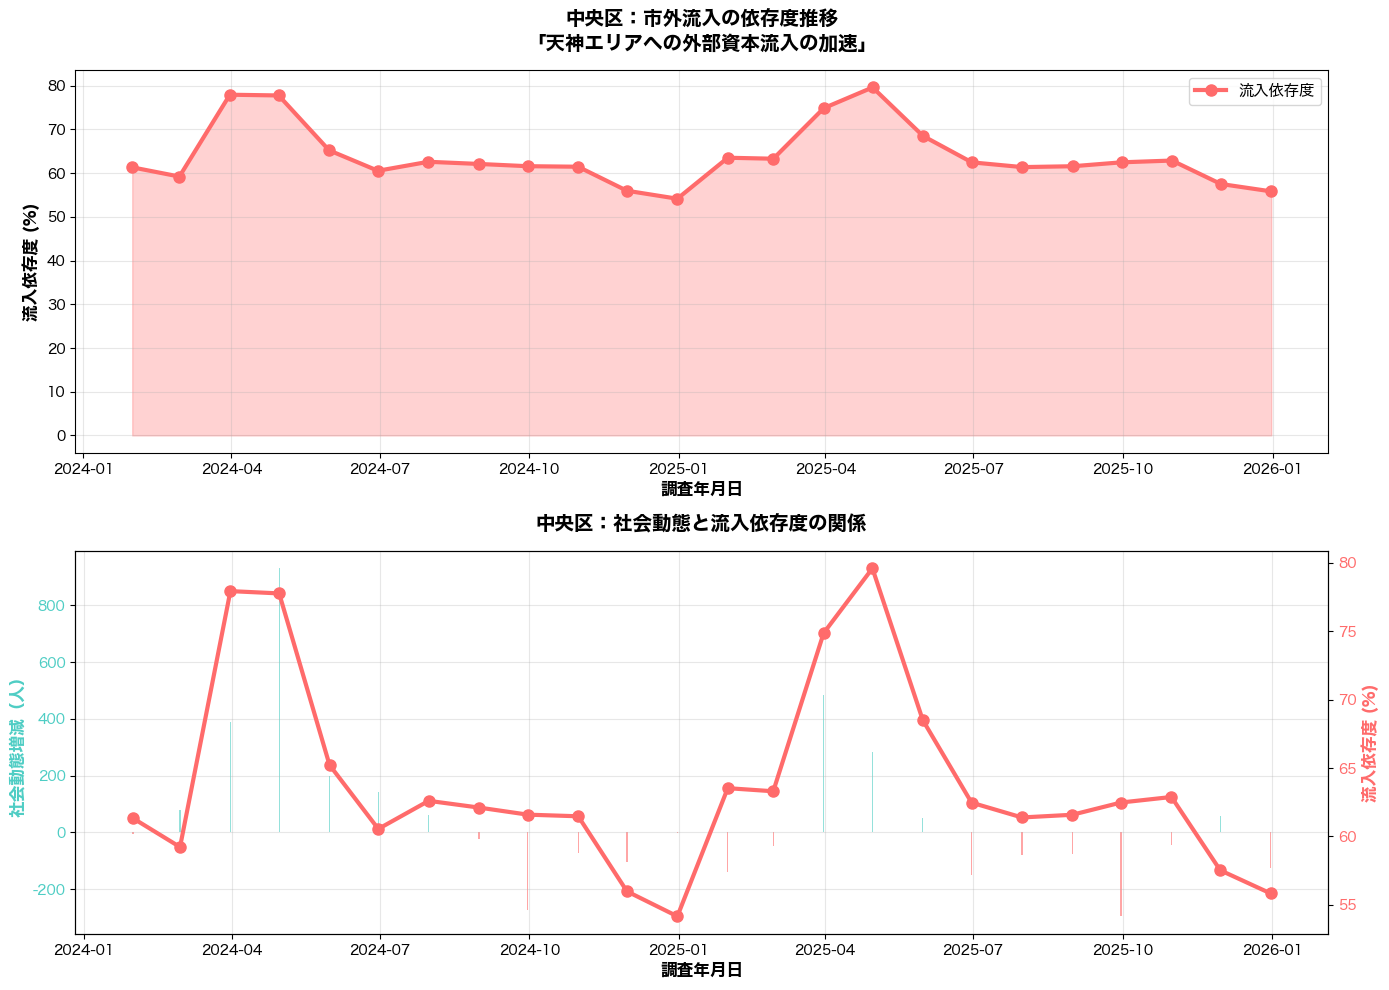


✓ グラフを保存しました: chuo_inflow_dependency.png


In [ ]:
# ==============================================================================
# セクション3: 中央区の時系列分析とビジュアライゼーション
# ==============================================================================

print("【中央区の流入依存度分析】")
print("="*80)

# 日付型に変換
df_jp['調査年月日'] = pd.to_datetime(df_jp['調査年月日'])

# 中央区のデータを抽出
df_chuo_trend = df_jp[df_jp['区分'] == '日本人_中央区'].sort_values('調査年月日')

print(f"\n【中央区】流入依存度の推移（{df_chuo_trend['調査年月日'].min().strftime('%Y年%m月')} ～ {df_chuo_trend['調査年月日'].max().strftime('%Y年%m月')}）")
print(df_chuo_trend[['調査年月日', '流入依存度', '社会動態_増減']])

# グラフ化
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Hiragino Maru Gothic Pro', 'Yu Gothic']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# グラフ1: 流入依存度の推移
ax1.plot(df_chuo_trend['調査年月日'], df_chuo_trend['流入依存度'] * 100, 
         marker='o', linewidth=3, markersize=8, color='#FF6B6B', label='流入依存度')
ax1.fill_between(df_chuo_trend['調査年月日'], df_chuo_trend['流入依存度'] * 100, alpha=0.3, color='#FF6B6B')
ax1.set_xlabel('調査年月日', fontsize=12, fontweight='bold')
ax1.set_ylabel('流入依存度 (%)', fontsize=12, fontweight='bold')
ax1.set_title('中央区：市外流入比率の推移', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11, loc='best')

# グラフ2: 社会動態増減との比較
ax2_twin = ax2.twinx()
bars = ax2.bar(df_chuo_trend['調査年月日'], df_chuo_trend['社会動態_増減'], 
               alpha=0.6, color=['#4ECDC4' if x > 0 else '#FF6B6B' for x in df_chuo_trend['社会動態_増減']], 
               label='社会動態増減（転入-転出）')
line = ax2_twin.plot(df_chuo_trend['調査年月日'], df_chuo_trend['流入依存度'] * 100, 
                      marker='o', linewidth=3, markersize=8, color='#FF6B6B', label='流入依存度')

ax2.set_xlabel('調査年月日', fontsize=12, fontweight='bold')
ax2.set_ylabel('社会動態増減（人）', fontsize=12, fontweight='bold', color='#4ECDC4')
ax2_twin.set_ylabel('流入依存度 (%)', fontsize=12, fontweight='bold', color='#FF6B6B')
ax2.set_title('中央区：社会動態と流入依存度の関係', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='y', labelcolor='#4ECDC4')
ax2_twin.tick_params(axis='y', labelcolor='#FF6B6B')

plt.tight_layout()
plt.savefig('../output_data/chuo_inflow_dependency.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ グラフを保存しました: chuo_inflow_dependency.png")

## 3. 中央区の流入依存度データサマリー

### 分析概要
- **分析対象地域**: 福岡市中央区
- **分析対象期間**: 令和6年1月～令和7年12月（24ヶ月）
- **主要指標**: 流入依存度（市外からの転入 ÷ 総転入数）

### 出力結果
- **グラフファイル**: `chuo_inflow_dependency.png`
- **グラフ1**: 中央区の市外流入比率の月別推移
- **グラフ2**: 社会動態増減と流入依存度の関係性（二軸グラフ）

### データ解釈上の注意
- 流入依存度が高い＝市外からの転入者が新規転入に占める割合が大きい
- 社会動態増減＝転入者数から転出者数を差し引いた値（プラス＝流入超過）
